# 03 - Your first language model: the bigram

It is time to actually train something. The **bigram** model is the simplest language model there is: to predict the next character, it looks at the current character and nothing before it. (Imagine trying to guess the next word in a sentence when you are allowed to see only the single word immediately before it. That is the handicap it works under.)

It is a weak model, but building it lays down the entire skeleton we reuse for the GPT: a forward pass, then the loss, then the backward pass (the gradients), then the update, then generation. We will even work out the gradient by hand and then check it against a brute-force numerical estimate.

In [1]:
# Colab setup -- fetch the files this notebook needs.
# (Does nothing when run locally in the course folder.)
import os, urllib.request
BASE = ("https://raw.githubusercontent.com/waze"
        "emlabs/llm-book-code/main/")
for f in ['data/input.txt']:
    if not os.path.exists(f):
        d = os.path.dirname(f)
        if d: os.makedirs(d, exist_ok=True)
        urllib.request.urlretrieve(BASE + f, f)
        print("downloaded", f)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import os, urllib.request</code>: two standard-library toolboxes: checking files on disk, and downloading from the web.</li>
<li><code>BASE = (...)</code>: the web address of this course's folder on GitHub, split over two lines (Python glues adjacent strings together).</li>
<li><code>for f in [...]</code>: loop over the file names this notebook needs.</li>
<li><code>if not os.path.exists(f)</code>: only download what is missing -- running locally, everything already exists, so nothing happens.</li>
<li><code>os.makedirs(d, exist_ok=True)</code>: create the folder for the file if it has one (<code>exist_ok</code> means don't complain if it's already there).</li>
<li><code>urllib.request.urlretrieve(...)</code>: download the file and save it under the same name here.</li>
</ul>
</details>

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
np.random.seed(1337)

# --- setup from notebook 02 (tokenizer + data) ---
text = Path("data/input.txt").read_text()
chars = sorted(set(text)); vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]; decode = lambda ids: "".join(itos[i] for i in ids)
data = np.array(encode(text), dtype=np.int64)
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)
print("vocab:", vocab_size, " dataset:", len(data))

vocab: 65  dataset: 1115394


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import numpy as np ...</code>: load the toolboxes (NumPy, Path for files, matplotlib for plots) and seed the randomness so your run matches the saved outputs.</li>
<li><code>text = Path("data/input.txt").read_text()</code>: read the whole Shakespeare file into one string.</li>
<li><code>chars = sorted(set(text)); vocab_size = len(chars)</code>: the distinct characters, in order, and how many there are (65) -- the vocabulary, exactly as in notebook 02.</li>
<li><code>stoi = {...}; itos = {...}</code>: the character&harr;id lookup tables.</li>
<li><code>encode = lambda s: ...; decode = lambda ids: ...</code>: one-line functions to turn text into ids and back.</li>
<li><code>data = np.array(encode(text), dtype=np.int64)</code>: the entire book as a long array of integer ids.</li>
<li><code>def softmax(x, axis=-1): ...</code>: the scores-to-probabilities helper from notebook 01, squeezed onto two lines (the semicolons just chain statements).</li>
<li>Nothing new here -- this cell just replays notebooks 01-02 so this notebook stands on its own.</li>
</ul>
</details>

## The model

The entire model is a single table of numbers called `W`, with a size of `(vocab, vocab)`, here 65 by 65. You can read it like a reference table: row `c` holds the scores for "which character tends to come after character `c`." Those raw scores are the **logits**, and softmax later turns a row into probabilities over the next character.

The forward pass is therefore almost nothing: to predict what follows character `x`, you simply take row `x` of `W`. In short, `logits = W[x]`, then softmax, gives probabilities over the next character.

(The code comment "selecting rows IS the matmul with one-hots" points to a neat fact. Picking row `x` gives the same answer as multiplying `W` by a list that is all 0s except for a single `1` in position `x`, which is called a "one-hot" list. Taking the row directly is just the fast version of that multiplication.)

A fresh `W` is filled with tiny random numbers, so every row is nearly flat and the model has no opinions yet. That is why the starting loss lands right at `ln(65) = 4.17`, which is the cross-entropy score for guessing all 65 characters as equally likely (notebook 01).

In [3]:
W = np.random.randn(vocab_size, vocab_size) * 0.01    # the only parameters

def forward(x):                 # x: (B,) current-char ids
    logits = W[x]               # (B, vocab) - selecting rows IS the matmul with one-hots
    return logits

def loss_fn(logits, y):         # cross-entropy of the true next chars y
    p = softmax(logits)
    return -np.mean(np.log(p[np.arange(len(y)), y] + 1e-9))

# sanity: an untrained model should have loss ~ ln(vocab_size)
xb = data[:1000]; yb = data[1:1001]
print("initial loss:", round(loss_fn(forward(xb), yb), 4), " | ln(vocab) =", round(np.log(vocab_size), 4))

initial loss: 4.1738  | ln(vocab) = 4.1744


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>W = np.random.randn(vocab_size, vocab_size) * 0.01</code>: a 65&times;65 grid of tiny random numbers. Row <code>c</code> will hold the scores for "what comes after character c." Multiplying by 0.01 keeps it near zero so the model starts with no opinions. This grid is the <i>entire</i> model.</li>
<li><code>def forward(x):</code>: the prediction step; <code>x</code> is a whole batch of current-character ids at once.</li>
<li><code>logits = W[x]</code>: fancy indexing: for each id in the batch, grab that row of W. In goes a list of ids; out comes a grid of scores, one row of 65 per example.</li>
<li><code>def loss_fn(logits, y):</code>: measures how wrong the predictions are against the true next characters <code>y</code>.</li>
<li><code>p = softmax(logits)</code>: turn each row of scores into probabilities.</li>
<li><code>p[np.arange(len(y)), y]</code>: pairwise pick: for row 0 take column <code>y[0]</code>, for row 1 column <code>y[1]</code>, and so on -- "the probability each example gave its own correct answer." <code>np.arange(n)</code> is just 0,1,...,n-1.</li>
<li><code>+ 1e-9</code>: add a microscopic amount so we never take log of exactly 0 (which would blow up to infinity).</li>
<li><code>-np.mean(np.log(...))</code>: the average surprise across the batch: cross-entropy from notebook 01, as one number.</li>
<li><code>xb = data[:1000]; yb = data[1:1001]</code>: the first 1000 characters and the same span shifted by one: each character paired with the one that follows.</li>
<li>The print shows the untrained loss landing on <code>ln(65) = 4.17</code>: exactly the score for "no idea, all 65 equally likely."</li>
</ul>
</details>

### Actually look at `W`

The paragraphs above keep calling `W` "a 65x65 table of tiny numbers with no opinions yet." Rather than take that on trust, let's print it and check every word of that claim by eye.

In [4]:
# The entire model, made visible.
print("W.shape:", W.shape, " -> rows = current char, cols = next char\n")

print("top-left corner W[:4, :6] (raw logits -- all tiny, near zero):")
print(np.round(W[:4, :6], 4))

# One row is the model's whole opinion about "what follows this character".
# Fresh, that row is near-flat, so softmax turns it into a near-uniform guess.
row = softmax(W[stoi["q"]])
best = np.argsort(row)[::-1][:3]
print("\nafter 'q', the untrained model's top-3 next characters:")
for j in best:
    print(f"   {itos[j]!r:>4}  p = {row[j]:.4f}")
print(f"a flat, no-opinion guess is 1/65 = {1/vocab_size:.4f}  <- essentially the same")

W.shape: (65, 65)  -> rows = current char, cols = next char

top-left corner W[:4, :6] (raw logits -- all tiny, near zero):
[[-0.007  -0.0049 -0.0032 -0.0176  0.0021 -0.0201]
 [ 0.0076 -0.0158  0.002   0.0009  0.0064 -0.0079]
 [ 0.0056 -0.0118 -0.0047 -0.0174 -0.     -0.0217]
 [-0.0239 -0.0044  0.0122  0.0037 -0.0138 -0.0068]]

after 'q', the untrained model's top-3 next characters:
    '?'  p = 0.0158
    'Z'  p = 0.0157
    'w'  p = 0.0157
a flat, no-opinion guess is 1/65 = 0.0154  <- essentially the same


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>print("W.shape:", ...)</code>: confirm the table is 65&times;65. The row index is the character you are standing on now; the column index is a character that might come next.</li>
<li><code>print(np.round(W[:4, :6], 4))</code>: peek at one small corner of W. Every number is a tiny random value near zero -- this is what "starts with no opinions" literally looks like.</li>
<li><code>row = softmax(W[stoi["q"]])</code>: take the row for 'q' and turn its raw scores into next-character probabilities.</li>
<li><code>np.argsort(row)[::-1][:3]</code>: pull out the three characters the model currently rates highest after 'q'.</li>
<li>The print shows those top-3 probabilities sitting right on top of <code>1/65 = 0.0154</code>: no real preference yet, which is exactly why the starting loss equals <code>ln(65)</code>.</li>
</ul>
</details>

### Watch one character go through

The readers above say what each line *does*, and the loss says where it all lands. What you have not seen is the numbers in between. They are worth watching once, slowly, on a single character, because every model in the rest of this course does exactly this and only ever does it faster.

In [5]:
x1, y1 = data[0], data[1]
print("current char :", repr(decode([x1])), "id", x1)
print("true next    :", repr(decode([y1])), "id", y1)


current char : 'F' id 18
true next    : 'i' id 47


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>x1, y1 = data[0], data[1]</code>: the very first pair in the dataset: one character and the one that follows it.</li>
<li><code>print(...)</code>: the text opens "First Citizen", so the first lesson in the whole dataset is "after F comes i". A good model gives <code>i</code> a high probability.</li>
</ul>
</details>

Step one, look up row 18 of `W`:

In [6]:
row = forward(x1)
print("row shape :", row.shape)
print("first 6   :", np.round(row[:6], 4))


row shape : (65,)
first 6   : [ 0.0082 -0.001   0.0081  0.0097 -0.0075 -0.0086]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>row = forward(x1)</code>: the forward pass for one id is simply row 18 of the table.</li>
<li><code>print(&quot;row shape :&quot;, row.shape)</code>: <code>(65,)</code> &mdash; sixty-five raw scores, one for every character that could come next.</li>
<li><code>print(&quot;first 6   :&quot;, np.round(row[:6], 4))</code>: all of them within a hair of zero. That is the <code>* 0.01</code> doing its work.</li>
</ul>
</details>

Step two, softmax turns scores into probabilities:

In [7]:
p1 = softmax(row)
print("first 6      :", np.round(p1[:6], 4))
print("they sum to  :", round(float(p1.sum()), 6))
print("1/65 is      :", round(1 / vocab_size, 6))
print("p(true next) :", round(float(p1[y1]), 6))


first 6      : [0.0155 0.0154 0.0155 0.0155 0.0153 0.0152]
they sum to  : 1.0
1/65 is      : 0.015385
p(true next) : 0.015325


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>p1 = softmax(row)</code>: turn the 65 scores into 65 probabilities.</li>
<li><code>print(&quot;they sum to  :&quot;, ...)</code>: 1.0, as probabilities must.</li>
<li><code>print(&quot;1/65 is      :&quot;, ...)</code>: every probability sits on the flat guess, 1/65.</li>
<li><code>print(&quot;p(true next) :&quot;, ...)</code>: the character that actually came next, <code>i</code>, was given 1.5% &mdash; no better than any of the other sixty-four.</li>
</ul>
</details>

Step three, turn that one probability into one number saying how wrong it was:

In [8]:
print("-log(p) :", round(float(-np.log(p1[y1])), 4))


-log(p) : 4.1783


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>-np.log(p1[y1])</code>: this is <code>-np.log(picked)</code> on a single example. A probability of 1.0 would score &minus;log(1) = 0: right answer, no surprise, nothing to fix. The smaller the probability given to the truth, the larger the number grows. 1.5% earns 4.18.</li>
</ul>
</details>

Everything that remains is doing that a thousand times at once, and the line readers stumble on is `p[np.arange(len(y)), y]`. It looks strange because it hands NumPy *two* lists where you might expect a row and a column. Try it on a grid small enough to check by eye:

In [9]:
small = np.array([[0.1, 0.7, 0.2],
                  [0.5, 0.3, 0.2]])
want = np.array([1, 0])
print(small[np.arange(2), want])


[0.7 0.5]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>small[np.arange(2), want]</code>: pair the two lists up position by position: <code>(0, 1)</code>, then <code>(1, 0)</code>. "Row 0, column 1" is 0.7; "row 1, column 0" is 0.5. One value comes back per row, and the second list decides <i>which</i> value. In <code>loss_fn</code> that second list is <code>y</code>, the true next characters, so the line means "each row's own probability for its own correct answer".</li>
</ul>
</details>

Now the whole batch at once:

In [10]:
logits = forward(xb)
p = softmax(logits)
picked = p[np.arange(len(yb)), yb]
print("logits shape :", logits.shape)
print("picked shape :", picked.shape)
print("first 4      :", np.round(picked[:4], 5))
print("mean -log    :",
      round(float(-np.mean(np.log(picked))), 4))


logits shape : (1000, 65)
picked shape : (1000,)
first 4      : [0.01532 0.01547 0.01557 0.01544]
mean -log    : 4.1738


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>logits = forward(xb)</code>: 1,000 ids go in, a 1000&times;65 grid of scores comes out.</li>
<li><code>picked = p[np.arange(len(yb)), yb]</code>: 1,000 probabilities picked from that grid, one per example.</li>
<li><code>print(&quot;mean -log    :&quot;, ...)</code>: one average stands in for all of them &mdash; and it is the same loss printed earlier, reached the slow way.</li>
</ul>
</details>

## The gradient, by hand

We need to know which way to nudge every number in `W` to lower the loss. The combination of softmax and cross-entropy has a famously clean answer: the gradient at the logits is simply the **probabilities minus the one-hot target**.

In plain terms: take the probabilities the model produced, then subtract 1 from the single position that was actually correct. Suppose the model predicted `[0.6, 0.3, 0.1]` and the true next character was at index 1. The gradient is `[0.6, 0.3 - 1, 0.1]`, which is `[0.6, -0.7, 0.1]`. A positive number means "this logit is too high, push it down," and a negative number means "push it up." So the rule automatically pushes the two wrong characters down and the correct one up, and the size of each push grows with how confidently wrong the model was. That is the whole learning signal.

Because `logits = W[x]` simply selected row `x`, that gradient flows straight back into row `x` of `W`. The same character appears many times in a batch, so the function `np.add.at` adds up every occurrence's nudge into the right row.

The cell below also runs a **gradient check**: it compares our formula against the brute-force numerical slope (nudge one number, watch how the loss moves) from notebook 01. The two agree to six decimal places, which is how you know the hand-derived gradient is correct. (The zeros are honest, and they come in whole rows: id 5 is the apostrophe and id 40 is the lowercase `b`, and neither character appears in this batch *as an input*, so `np.add.at` routes no gradient into row 5 or row 40 at all. A pair that merely never occurred, like `W[10,20]`, still gets a small positive gradient — "push down" — whenever its row's character shows up as an input.)

In [11]:
def backward(x, y):
    B = len(x)
    p = softmax(W[x])                 # (B, vocab)
    dlogits = p.copy()
    dlogits[np.arange(B), y] -= 1     # probs - one_hot(target)
    dlogits /= B                      # average over the batch
    dW = np.zeros_like(W)
    np.add.at(dW, x, dlogits)         # route each row's gradient back to W[x]
    return dW

# gradient check: compare our analytic dW to a numerical estimate on a few entries
xb, yb = data[:256], data[1:257]
dW = backward(xb, yb)
def num_grad(i, j, h=1e-4):
    global W
    W[i, j] += h; lp = loss_fn(forward(xb), yb)
    W[i, j] -= 2*h; lm = loss_fn(forward(xb), yb)
    W[i, j] += h
    return (lp - lm) / (2*h)
for (i, j) in [(10, 20), (5, 5), (40, 1)]:
    print(f"  W[{i},{j}]  analytic={dW[i,j]: .6f}  numerical={num_grad(i,j): .6f}")
print("they match -> our hand-derived gradient is correct")

  W[10,20]  analytic= 0.000359  numerical= 0.000359
  W[5,5]  analytic= 0.000000  numerical= 0.000000
  W[40,1]  analytic= 0.000000  numerical= 0.000000
they match -> our hand-derived gradient is correct


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def backward(x, y):</code>: the mirror of <code>forward</code>. Where <code>forward</code> sends a batch through W to get predictions, <code>backward</code> sends the blame the other way: the same batch goes in, and out comes <code>dW</code>, one gradient number for every entry of W &mdash; which way to nudge each one to lower the loss. The name is the convention every framework uses, PyTorch included.</li>
<li><code>B = len(x)</code>: how many examples are in this batch. Two lines below need it, so it gets a name.</li>
<li><code>p = softmax(W[x])</code>: the model's current probabilities for this batch.</li>
<li><code>dlogits = p.copy()</code>: start the gradient as a copy of those probabilities (<code>.copy()</code> so we don't accidentally change <code>p</code> itself).</li>
<li><code>dlogits[np.arange(B), y] -= 1</code>: subtract 1 at each example's correct answer. This is the clean <b>probabilities minus one-hot</b> rule from the text, applied to the whole batch at once: it pushes wrong characters down and the right one up.</li>
<li><code>dlogits /= B</code>: divide by the batch size, because the loss was an <i>average</i> over B examples.</li>
<li><code>dW = np.zeros_like(W)</code>: an all-zeros grid the same shape as W, to collect the gradient.</li>
<li><code>np.add.at(dW, x, dlogits)</code>: route each example's gradient back into row <code>x</code> of dW, <i>adding up</i> when the same character appears several times. (Plain <code>dW[x] += ...</code> would silently drop repeats -- this is the safe version.)</li>
<li><code>def num_grad(i, j, h=1e-4):</code>: the brute-force check: nudge one entry of W up then down (the <code>+= h</code> ... <code>-= 2*h</code> ... <code>+= h</code> dance restores it afterward) and measure how the loss moves -- rise over run.</li>
<li><code>for (i, j) in [(10, 20), ...]:</code>: spot-check three entries; the hand-derived gradient and the brute force agree to six decimals, so the formula is correct.</li>
</ul>
</details>

### Why the gradient is divided by `B`

The `/= B` line is easy to read as a convention somebody chose. It is not optional, and it is not arbitrary. The loss was not the *sum* of B surprises, it was that sum multiplied by 1/B, and a constant multiplier carries straight through a slope. Drop the division and check the same weight against a measured slope:

In [12]:
def backward_no_div(x, y):
    b = len(x)
    p = softmax(W[x])
    d = p.copy()
    d[np.arange(b), y] -= 1
    dW2 = np.zeros_like(W)     # note: no /= b
    np.add.at(dW2, x, d)
    return dW2

wrong = backward_no_div(xb, yb)
print("measured slope :", round(num_grad(10, 20), 6))
print("with    /= B   :", round(dW[10, 20], 6))
print("without /= B   :", round(wrong[10, 20], 6))
print("ratio          :", round(wrong[10, 20] / dW[10, 20], 1))


measured slope : 0.000359
with    /= B   : 0.000359
without /= B   : 0.091946
ratio          : 256.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def backward_no_div(x, y):</code>: the same gradient as <code>backward</code>, with the one line that averages over the batch left out.</li>
<li><code>wrong = backward_no_div(xb, yb)</code>: compute the un-averaged gradient for the same batch.</li>
<li><code>print(&quot;measured slope :&quot;, round(num_grad(10, 20), 6))</code>: reality: the slope measured by nudging that one weight and dividing rise by run.</li>
<li><code>print(&quot;ratio          :&quot;, ...)</code>: the undivided version is wrong by a factor of 256, and 256 is exactly <code>B</code>. The measurement agrees only with the divided one. This is the average in <code>loss_fn</code> reaching forward to set the size of every step the model will ever take: had we summed instead, doubling the batch size would silently double the learning rate too.</li>
</ul>
</details>

### See the learning signal for a single example

"Probabilities minus the one-hot target" is a tidy phrase. Here it is as an actual picture, for one real pair from the batch: every wrong character gets a small positive nudge (meaning "push this logit down"), and the single correct character gets one big negative nudge ("push this one up"). That whole shape is the gradient.

current char 'F'  ->  true next char 'i'
prob the model put on the correct answer : 0.0153   (we want this near 1)
gradient at the correct column           : -0.9847   (negative -> push that logit UP)
gradient at each of the 64 other columns : ~+0.0154    (positive -> push them DOWN)


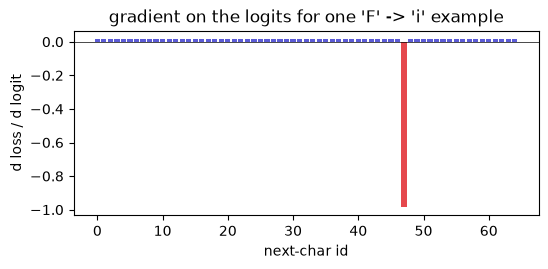

In [13]:
# Rebuild the gradient for ONE example and look at the signal, number by number.
xi, yi = int(xb[0]), int(yb[0])            # current char, true next char
probs = softmax(W[xi])                     # the model's guess for this row
g = probs.copy(); g[yi] -= 1               # probs - one_hot(target): the whole signal

print(f"current char {itos[xi]!r}  ->  true next char {itos[yi]!r}")
print(f"prob the model put on the correct answer : {probs[yi]:.4f}   (we want this near 1)")
print(f"gradient at the correct column           : {g[yi]:+.4f}   (negative -> push that logit UP)")
other = g[np.arange(vocab_size) != yi]
print(f"gradient at each of the 64 other columns : ~{other.mean():+.4f}    (positive -> push them DOWN)")

plt.figure(figsize=(6, 2.4))
colors = np.where(np.arange(vocab_size) == yi, "#e5484d", "#5b5bd6")
plt.bar(range(vocab_size), g, color=colors)
plt.axhline(0, color="k", lw=.5)
plt.title(f"gradient on the logits for one '{itos[xi]}' -> '{itos[yi]}' example")
plt.xlabel("next-char id"); plt.ylabel("d loss / d logit"); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>xi, yi = int(xb[0]), int(yb[0])</code>: take the first pair in the batch -- one current character and the character that truly followed it.</li>
<li><code>probs = softmax(W[xi])</code>: the untrained model's probabilities for what comes after <code>xi</code> (all near 1/65).</li>
<li><code>g = probs.copy(); g[yi] -= 1</code>: the exact rule from the text -- start from the probabilities, then subtract 1 at the one correct answer.</li>
<li>The prints spell the signal out: the correct column becomes a big negative number (about -0.98, "push up hard"), while all 64 others stay small and positive ("push down gently").</li>
<li><code>plt.bar(...)</code>: draw it. The lone red bar diving toward -1 is the correct character; the flat blue line just above zero is every wrong character. Training is just doing this for a whole batch and stepping <code>W</code> the opposite way.</li>
</ul>
</details>

## The training loop

Here is the loop that appears in every notebook from this point on. It is worth committing to memory, because only the model in the middle ever changes:

1. **sample a batch** of `(current character, next character)` pairs -- a fresh *random* handful each step (that randomness is what puts the "stochastic" in **stochastic gradient descent**, the name we meet in notebook 07),
2. **forward**: compute the logits,
3. **loss**: measure how surprised the model was, using cross-entropy,
4. **backward**: compute the gradient, the downhill direction for every number in `W`,
5. **update**: step `W` a little way downhill, written `W -= lr * gradient`,
6. repeat thousands of times.

Watch the loss fall from about `4.17` (random guessing) towards about `2.45`, which is the best any one-character-of-memory model can do on this text. We will actually compute that ceiling in a moment. (The learning rate here is a large `30`, which looks surprising after notebook 01's `0.1`. It is fine because this model is so simple and its gradients are very small. The right step size is always specific to the problem; you tune it until training is both fast and stable.)

Before the loop, notice what is *missing* from the shapes here, because it is the first thing to trip on coming from notebook 02. There, a batch was a `(batch_size, block_size)` grid: four chunks of eight characters, `x.shape` of `(4, 8)`. Here `x` is `(B,)` — single characters, with no second dimension at all. Where did the block size go?

Nowhere; a bigram has no use for one. This model predicts the next character from the current character and nothing else, so its context is exactly one token long. Hand it a chunk of eight and seven of those characters are ones it is structurally incapable of reading. A "block" only earns its place once the model can look at more than one position at a time, which is what attention buys in notebook 05 — that is the `T` in every shape there — and it is called `block_size` again in notebook 07, once PyTorch is doing the bookkeeping.

The same idea explains the `- 1` when the positions are drawn. Notebook 02 stopped `block_size` characters short of the end so a whole chunk would fit. Here only one character has to fit after the one you land on, so one short of the end is enough.

### One full step of the loop, unrolled

The loop below runs six lines thousands of times. Before trusting it, let's execute a single pass and print what each variable holds, so none of it stays abstract. Every symbol the step touches:

| symbol | shape | what it holds |
| --- | --- | --- |
| `x` | (B,) | the current-character ids of the batch |
| `y` | (B,) | the id that actually follows each one |
| `logits = W[x]` | (B, 65) | a raw score for every possible next char |
| `dW` | (65, 65) | how to nudge every weight to lower the loss |

(B is the batch size, 1024 here -- the same batch the loop below draws.)

In [14]:
# One real pass of the loop, narrated. We draw a batch the same way the loop does
# (a private RNG, so the seeded loop below still reproduces its numbers), then
# read off what each step produces.
rng = np.random.default_rng(0)
B = 1024
ix = rng.integers(0, len(data) - 1, size=B)
xb1, yb1 = data[ix], data[ix + 1]              # step 1: B (current -> next) pairs

print(f"step 1  a batch of {B} (current -> next) pairs; the first 6:")
for cx, cy in zip(xb1[:6], yb1[:6]):
    print(f"          id {cx:>2} {itos[cx]!r:>4}   ->   id {cy:>2} {itos[cy]!r:>4}")

logits = forward(xb1)                          # step 2: forward
L = loss_fn(logits, yb1)                       # step 3: loss
dW = backward(xb1, yb1)                         # step 4: backward
rows_touched = int((dW != 0).any(axis=1).sum())
print(f"\nstep 2  forward : logits.shape = {logits.shape}  ({B} rows, a 65-long score vector each)")
print(f"step 3  loss    : {L:.4f} nats   (near ln 65 = 4.17 -- the model is still untrained)")
print(f"step 4  backward: dW.shape = {dW.shape}; {rows_touched} of 65 rows are nonzero")
print(f"                  -> a character only gets a nudge if it appeared in the batch")

i, jt = int(xb1[0]), int(yb1[0])               # step 5: the update rule, on one weight
print(f"step 5  update  : W -= lr * dW.  dW[{i},{jt}] = {dW[i, jt]:+.5f} for the seen "
      f"'{itos[i]}'->'{itos[jt]}' pair,")
print(f"                  so W[{i},{jt}] steps {W[i, jt]:+.4f} -> {W[i, jt] - 30.0 * dW[i, jt]:+.4f}   (lr=30)")
print("step 6  repeat this thousands of times -- that is the whole cell below.")

step 1  a batch of 1024 (current -> next) pairs; the first 6:
          id 52  'n'   ->   id 57  's'
          id 51  'm'   ->   id 47  'i'
          id 46  'h'   ->   id 43  'e'
          id 58  't'   ->   id 46  'h'
          id 53  'o'   ->   id 59  'u'
          id 51  'm'   ->   id  6  ','

step 2  forward : logits.shape = (1024, 65)  (1024 rows, a 65-long score vector each)
step 3  loss    : 4.1737 nats   (near ln 65 = 4.17 -- the model is still untrained)
step 4  backward: dW.shape = (65, 65); 56 of 65 rows are nonzero
                  -> a character only gets a nudge if it appeared in the batch
step 5  update  : W -= lr * dW.  dW[52,57] = -0.00019 for the seen 'n'->'s' pair,
                  so W[52,57] steps +0.0103 -> +0.0159   (lr=30)
step 6  repeat this thousands of times -- that is the whole cell below.


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>rng = np.random.default_rng(0); ix = rng.integers(...)</code>: draw 1024 random positions, exactly as the training loop does (a private RNG so the seeded loop below still reproduces its numbers).</li>
<li><code>xb1, yb1 = data[ix], data[ix + 1]</code>: turn those positions into (current char, next char) pairs -- the first six are printed so you see what feeds the step.</li>
<li><code>forward / loss_fn / backward</code>: run the three core functions once and report the shape or value each produces -- a (1024, 65) grid of logits, one loss number, a (65, 65) gradient.</li>
<li><code>rows_touched</code>: counts the nonzero rows of <code>dW</code>. Read it inside out: <code>dW != 0</code> compares every entry against zero and gives back a grid of <code>True</code>/<code>False</code> the same shape as <code>dW</code>; <code>.any(axis=1)</code> collapses each row to one verdict, "is anything in this row nonzero?"; <code>.sum()</code> counts the <code>True</code>s, because arithmetic on True/False treats them as 1 and 0. A character only earns a gradient if it appeared in the batch; with 1024 samples that is nearly all of them.</li>
<li>The step-5 line shows the real update on one weight -- the gradient, and where <code>W -= lr * dW</code> moves it -- and step 6 is just "do it again," which is the loop in the next cell.</li>
</ul>
</details>

final train loss (avg of last 200 steps): 2.4613


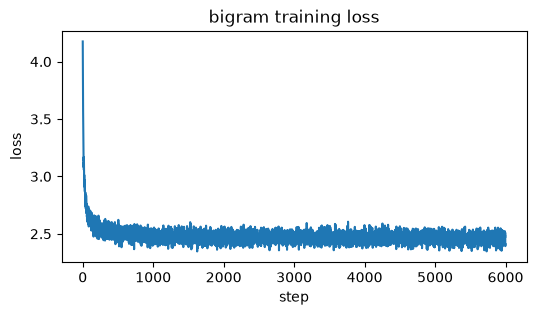

In [15]:
W = np.random.randn(vocab_size, vocab_size) * 0.01   # fresh start
lr, steps, batch_size = 30.0, 6000, 1024
losses = []
for step in range(steps):
    ix = np.random.randint(0, len(data) - 1, size=batch_size)
    x, y = data[ix], data[ix + 1]
    logits = forward(x)
    losses.append(loss_fn(logits, y))
    W -= lr * backward(x, y)

# one batch is a noisy reading (easy and hard stretches of text exist),
# so report an average over the last 200 steps
print("final train loss (avg of last 200 steps):", round(float(np.mean(losses[-200:])), 4))

plt.figure(figsize=(6, 3))
plt.plot(losses); plt.title("bigram training loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>W = np.random.randn(...) * 0.01</code>: a fresh random start, so training begins from scratch.</li>
<li><code>lr, steps, batch_size = 30.0, 6000, 1024</code>: three settings on one line: step size, number of updates, examples per update.</li>
<li><code>for step in range(steps):</code>: repeat the update 6000 times.</li>
<li><code>ix = np.random.randint(0, len(data) - 1, size=1024)</code>: 1024 random positions in the book.</li>
<li><code>x, y = data[ix], data[ix + 1]</code>: the characters at those positions and the characters right after: 1024 (current &rarr; next) pairs.</li>
<li><code>losses.append(loss_fn(logits, y))</code>: record the loss each step so we can plot the learning curve.</li>
<li><code>W -= lr * backward(x, y)</code>: the whole learning rule in one line: step the table downhill along its gradient.</li>
<li><code>np.mean(losses[-200:])</code>: average of the <i>last</i> 200 entries (negative indexing counts from the end) -- a steadier reading than one noisy step.</li>
</ul>
</details>

### What did `W` actually learn?

Fresh, `W` was flat noise. After 6000 steps it has opinions -- so let's look at the whole table again, this time as a heatmap. Each row is a current character, each column a possible next character, and brighter means higher probability. Every bright cell is a real regularity the model dug out of Shakespeare on its own.

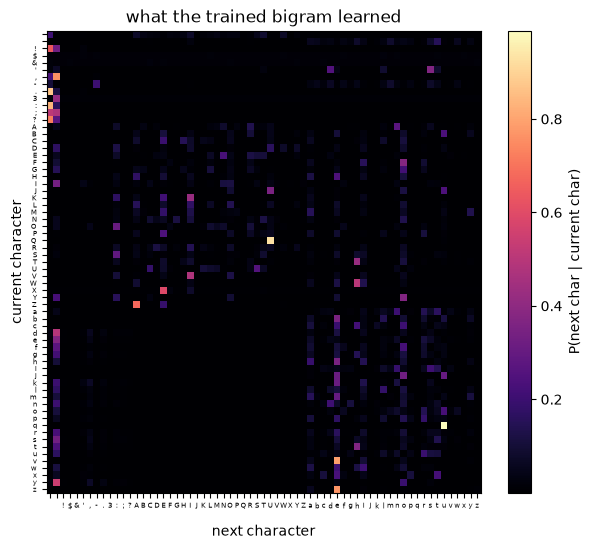

after     'q': most likely next char is  'u'  (p = 0.99)
after     '.': most likely next char is '\n'  (p = 0.87)
after   space: most likely next char is  't'  (p = 0.15)


In [16]:
# Same table as before, now trained. Turn each row into next-char probabilities and look.
P = softmax(W, axis=1)

plt.figure(figsize=(7, 6))
plt.imshow(P, cmap="magma", aspect="auto")
plt.colorbar(label="P(next char | current char)")
plt.xticks(range(vocab_size), [itos[i] for i in range(vocab_size)], fontsize=5)
plt.yticks(range(vocab_size), [itos[i] for i in range(vocab_size)], fontsize=5)
plt.xlabel("next character"); plt.ylabel("current character")
plt.title("what the trained bigram learned"); plt.show()

# Read a few rows back in plain English -- the model was never told any of this.
for c in ["q", ".", " "]:
    r = P[stoi[c]]; j = int(r.argmax())
    name = "space" if c == " " else repr(c)
    print(f"after {name:>7}: most likely next char is {itos[j]!r:>4}  (p = {r[j]:.2f})")

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>P = softmax(W, axis=1)</code>: turn every row of the trained table into a clean probability distribution over the next character (<code>axis=1</code> normalises along each row).</li>
<li><code>plt.imshow(P, cmap="magma")</code>: draw the 65&times;65 table as an image -- dark = unlikely, bright = likely. The single brightest cell in the whole grid is row 'q', column 'u'.</li>
<li><code>plt.xticks / plt.yticks</code>: label the axes with the actual characters instead of raw ids, so you can read the structure straight off the picture.</li>
<li>The loop prints the top prediction for three rows: 'q' -&gt; 'u' almost certainly, '.' -&gt; a newline (sentences end lines), and a space -&gt; a common word-starting letter. Compare that to the flat 'q' row we printed before training.</li>
</ul>
</details>

## The ceiling: how good can a bigram ever get?

Here is a question worth pausing on: if we trained forever, how low could this loss go? Not to zero. Even a perfect bigram is stuck guessing from a single character, and one character genuinely does not determine the next one, since after a space almost anything can follow. That leftover, unavoidable uncertainty sets a hard floor under the loss.

We can compute that floor directly, with no training at all: count every neighbouring pair of characters in the text, turn the counts into exact probabilities, and measure their average surprise (the cross-entropy from notebook 01). The answer comes out at about `2.45` nats, which is exactly where the training curve flattened out. (A *nat* is just the unit this kind of loss is measured in when the natural logarithm is used; the number itself is what matters.) The little model is not being lazy; it has learned everything that one character of context can teach.

This idea, that a model's loss floor is set by how much context it can see, is the strongest single argument for attention, and it is where the course is heading next.

In [17]:
# Count every adjacent pair of characters in the data, turn each row of counts into
# probabilities, and measure the loss of those PERFECT bigram probabilities.
# No model that sees only one character of context can ever beat this number --
# it is the built-in uncertainty of "next char given current char" on this text.
counts = np.zeros((vocab_size, vocab_size))
np.add.at(counts, (data[:-1], data[1:]), 1)
p = counts / np.maximum(counts.sum(axis=1, keepdims=True), 1)
row_weight = counts.sum(axis=1) / counts.sum()            # how often each char occurs
with np.errstate(divide="ignore", invalid="ignore"):
    row_entropy = -np.nansum(np.where(p > 0, p * np.log(p), 0.0), axis=1)
optimum = float(np.nansum(row_weight * row_entropy))
print(f"bigram optimum on this text: {optimum:.4f} nats")
print("our trained model sits essentially at this ceiling -- the only way past it is more context")

bigram optimum on this text: 2.4526 nats
our trained model sits essentially at this ceiling -- the only way past it is more context


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>counts = np.zeros((65, 65))</code>: a grid of zeros; <code>counts[a, b]</code> will tally "how many times did character b follow character a?"</li>
<li><code>np.add.at(counts, (data[:-1], data[1:]), 1)</code>: walk every adjacent pair in the book in one shot (all-but-last paired with all-but-first) and add 1 in the matching slot.</li>
<li><code>p = counts / np.maximum(counts.sum(axis=1, keepdims=True), 1)</code>: turn each row of tallies into fractions that sum to 1: the true next-character probabilities. <code>np.maximum(..., 1)</code> avoids dividing by zero for a character that never has a follower.</li>
<li><code>row_weight = counts.sum(axis=1) / counts.sum()</code>: how often each character actually occurs, so common characters count more in the average.</li>
<li><code>row_entropy = -np.nansum(np.where(p > 0, p * np.log(p), 0.0), axis=1)</code>: the average surprise for each current-character (notebook 01's cross-entropy), with zero-probability slots safely treated as zero surprise.</li>
<li><code>optimum = np.nansum(row_weight * row_entropy)</code>: the weighted average: <b>2.4526</b>. No one-character model, trained or not, can beat this floor.</li>
<li><code>np.errstate(...)</code>: housekeeping that silences harmless "log of zero" warnings.</li>
</ul>
</details>

### The whole story in one plot

We now have three numbers on the same scale: the random starting loss `ln(65) = 4.17`, our trained bigram's `2.46`, and the perfect bigram ceiling `2.45`. Drawing all three on the training curve shows the entire arc at a glance -- the loss dives off the random line and then settles right onto the ceiling, with essentially no gap left to close.

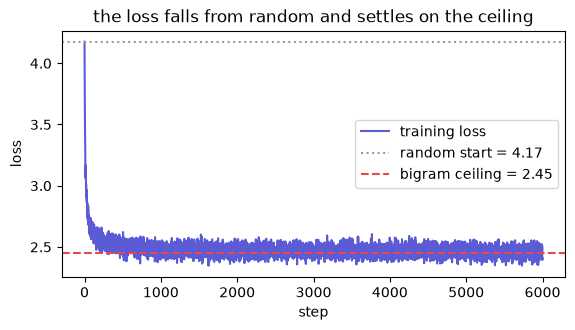

gap left between our model and the perfect bigram: +0.0087 nats
essentially zero -- one character of context has nothing left to give


In [18]:
# Put the training curve and the two reference levels on one axis.
plt.figure(figsize=(6.5, 3.2))
plt.plot(losses, color="#5b5bd6", label="training loss")
plt.axhline(np.log(vocab_size), color="#999", ls=":", label=f"random start = {np.log(vocab_size):.2f}")
plt.axhline(optimum, color="#e5484d", ls="--", label=f"bigram ceiling = {optimum:.2f}")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend()
plt.title("the loss falls from random and settles on the ceiling"); plt.show()

gap = float(np.mean(losses[-200:])) - optimum
print(f"gap left between our model and the perfect bigram: {gap:+.4f} nats")
print("essentially zero -- one character of context has nothing left to give")

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>plt.plot(losses)</code>: the same training curve as before -- loss on the y-axis, step on the x-axis.</li>
<li><code>plt.axhline(np.log(vocab_size), ls=":")</code>: a dotted line at 4.17, where an untrained model starts (pure guessing over 65 characters).</li>
<li><code>plt.axhline(optimum, ls="--")</code>: a dashed line at 2.45, the perfect-bigram ceiling we just computed from the raw counts.</li>
<li>The curve dives off the dotted line and then rides along the dashed one: the model learned everything a single character of context allows, then stopped.</li>
<li>The final print measures the leftover gap between our trained model and that ceiling -- it comes out essentially zero.</li>
</ul>
</details>

## Generate text

Generating text is a loop of "predict, draw at random, feed the result back in":

1. start from a character and read off its next-character probabilities,
2. **draw** a character from that set of probabilities. We *sample* (in effect rolling a weighted die) rather than always taking the single most likely character, so the text does not get stuck repeating itself,
3. feed that new character back in as the context, and repeat.

This style, in which each output is fed back in as the next input, is called **autoregressive** generation, and it is exactly how ChatGPT writes as well, one token at a time. The result here is gibberish with some structure: the model has learned which characters tend to follow which (a `q` pulls in a `u`, capital letters follow newlines, vowels and consonants alternate), but with only one character of memory it cannot assemble real words. That precise limitation is what attention fixes in notebook 05.

In [19]:
def generate(start, n=400, seed=0):
    rng = np.random.default_rng(seed)
    idx = stoi[start]; out = [idx]
    for _ in range(n):
        p = softmax(W[idx])
        idx = int(rng.choice(vocab_size, p=p))
        out.append(idx)
    return decode(out)

print(generate("T", 400))

Tha ETorness
V:

Whan ashe ysisin se myone omes p, t t hanof il omilte pthund: wend's.
Ro'stu twobyoun, wares sh s
STo t hethalof firor.
Thuirer it ter
D r, w's heayimatoray busiuthoifou ithe me y!
Tur?
PEROr mod Pe ithout TAnghas sano n thy winorit te yordo sprGofane i! t stwndvorounouepo id jor witor serery bend--makneat s bonct m buse n soth d, yockifastalore T:

n ld thid me ct tindisthitigo in


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def generate(start, n=400, seed=0):</code>: write text starting from a character; <code>seed</code> makes the dice rolls repeatable.</li>
<li><code>idx = stoi[start]; out = [idx]</code>: look up the starting character's id and begin the output list with it.</li>
<li><code>for _ in range(n):</code>: repeat n times (the <code>_</code> means "loop counter unused").</li>
<li><code>p = softmax(W[idx])</code>: the model's probabilities for what follows the current character.</li>
<li><code>idx = int(rng.choice(vocab_size, p=p))</code>: the dice roll: pick one of the 65 ids <i>according to those probabilities</i> (likely characters come up often, unlikely ones rarely).</li>
<li><code>out.append(idx)</code>: record the pick, then loop -- feeding each new character back in as context. That feed-back-in is autoregeneration.</li>
<li><code>decode(out)</code>: ids back to text so you can read what it wrote.</li>
</ul>
</details>

## Recap

You built and trained a real, if tiny, language model, worked out its gradient by hand, and sampled text from it. The skeleton (forward, loss, backward, update, generate) never changes from here; only the model in the middle grows more capable.

Two obstacles stand in the way next:
1. Writing gradients by hand will not scale to a deep network, so notebook 04 builds **autograd**, which works them out for us.
2. One character of context is hopeless, so notebook 05 introduces **attention**, which lets a token look back over the whole context.